In [1]:
## Packages Import
import numpy             as np
import matplotlib.pyplot as plt

In [2]:
## Utilities

def simpson_weights(n, h):
    """
    Return the combined weights for all nodes according to the Simpson's
    quadrature rule
    """
    assert n % 2 == 0, "Simpson's rule requires an even number of subintervals"
    weight = np.zeros(n)
    weight[0] = weight[-1] = h/3
    weight[1:-1:2] = 4*h/3
    weight[2:-1:2] = 2*h/3
    return weight

def finite_diff(n, h):
    """
    Second-order accurate finite differences method over the domain:
    - interior nodes: central difference
    - boundary nodes: one-sided difference
    """
    D = np.zeros((n, n))
    # Interior nodes
    for i in range(1, n-1):
        # Central finite difference - 2nd order accurate
        D[i, i-1] = -1/(2*h)
        D[i, i+1] =  1/(2*h)
    # Boundary nodes
    # One-sided finite difference - 2nd order accurate
    D[0, :3]   = [-3,  4, -1]/(2*h)     # root node (forward finite diff)
    D[-1, -3:] = [ 1, -4,  3]/(2*h)     # tip node (backward finite diff)
    return D

def inter_diff_operator(z, zeta):
    """
    Build the integral-differential operator relating downwash velocity at point P
    to the circulation over the lifting line; it does not account for scalar
    multiplicative constants
                    M -> v(zP) = 1/(4π) * M @ gamma
    """
    N1 = len(z)      # number of nodes (N+1)
    N  = len(zeta)   # number of cells (N)
    dz = z[1] - z[0]    # cell size

    # Integral kernel matrix
    weight = simpson_weights(N1, dz)    # quadrature weights (N+1, 1)
    H = np.zeros((N, N1))               # (N, N+1)
    for i in range(N):
        for j in range(N1):
            H[i, j] = weight[j] / (z[j] - zeta[i])
    # Differential matrix
    D = finite_diff(N1, dz)  # (N+1, N+1)
    # Full intregral-differential matrix
    M = np.dot(H, D)        # (N, N+1)
    return M

In [ ]:
b = 10       # wing span
s = b / 2   # wing semi-span

# Wing span discretization
N = 99     # number of cells (must be odd)
z = np.linspace(-s, s, N+1)         # cell nodes     (N+1, 1)
zeta = (z[1:] + z[:-1]) / 2         # cell centroids (N, 1)
M = inter_diff_operator(z, zeta)    # (N, N+1)

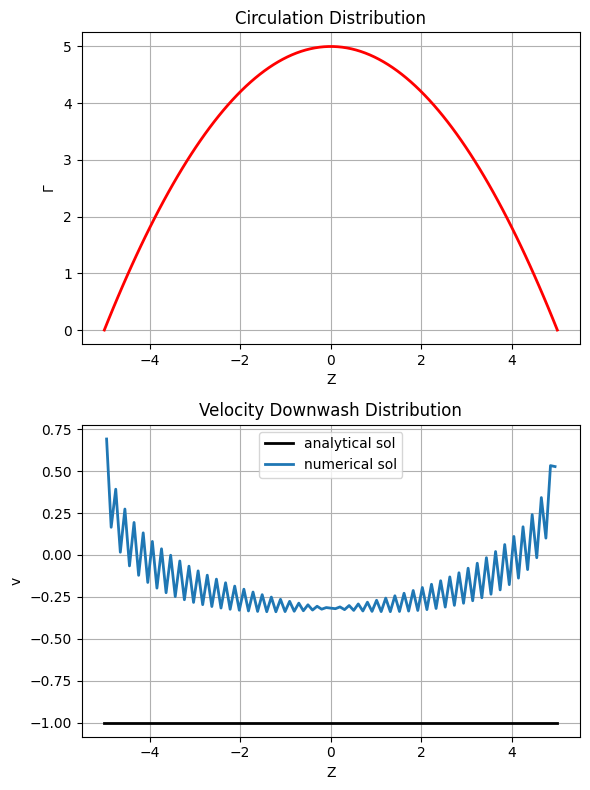

In [ ]:
# Test integral-differential operator against reference solution
g0 = 5                      # circulation @ origin
gamma = g0*(1 - (z/s)**2)   # elliptical circulation distribution
# Induced downwash velocity
v = 1/(4*np.pi) * np.dot(M, gamma)      # numerical solution
v_ref = -g0 / s                         # analytical solution

fig = plt.figure(figsize=(6, 8))
# Plot circulation distribution along span
ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(z, gamma, c='r', linewidth=2)
ax1.set_xlabel("Z")
ax1.set_ylabel(r'$\Gamma$')
ax1.set_title("Circulation Distribution")
ax1.grid(True)
# Plot downwash distribution along span
ax2 = fig.add_subplot(2, 1, 2)
ax2.plot(z, v_ref * np.ones(z.shape), c='k', linewidth=2, label="analytical sol")
ax2.plot(zeta, v,                            linewidth=2, label="numerical sol")
ax2.set_xlabel("Z")
ax2.set_ylabel("v")
ax2.legend()
ax2.set_title("Velocity Downwash Distribution")
ax2.grid(True)

fig.tight_layout()
plt.show()